In [2]:
from dotenv import load_dotenv
import os

load_dotenv()

import boto3
import os

session = boto3.Session(
    aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID"),
    aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY"),
    region_name=os.getenv("AWS_DEFAULT_REGION")
)

In [3]:
import mlflow

aws_path = os.getenv("AWS_INSTANCE_IP")
mlflow.set_tracking_uri(f"http://{aws_path}:5000")

In [16]:
from sklearn.metrics import accuracy_score, classification_report
import seaborn as sns
from lightgbm import LGBMClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import pandas as pd
import warnings
warnings.filterwarnings('ignore')


In [5]:
dataset = pd.read_csv('reddit_preprocessing.csv')

dataset.dropna(inplace = True)

In [6]:
X = dataset.clean_comment
y = dataset.category

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [8]:
tfidf_cleaned = TfidfVectorizer(ngram_range = (1,3), max_features = 10000)

X_train_tfidf_cleaned = tfidf_cleaned.fit_transform(X_train)
X_test_tfidf_cleaned = tfidf_cleaned.transform(X_test)

In [12]:
lightgbm_model = LGBMClassifier(
    objective = 'multiclass',
    num_class = 3,
    metric = 'multi_logloss',
    is_unbalanced = True,
    class_weight = 'balanced',
    reg_alpha = 0.1,
    reg_lambda = 0.1,
    learning_rate = 0.08081298097796712,
    n_estimators = 367,
    max_depth = 20,
    verbose = -1,
    verbosity = -1
)

logreg_model = LogisticRegression(
    max_iter = 1000, class_weight = 'balanced',solver = 'lbfgs')

knn_meta_learner = KNeighborsClassifier(n_neighbors = 5)

stacking_model = StackingClassifier(
    estimators = [
        ('lightgbm', lightgbm_model),
        ('logistic_regression',logreg_model)
    ],
    final_estimator = knn_meta_learner,
    cv = 5
)

stacking_model.fit(X_train_tfidf_cleaned, y_train)

/opt/homebrew/Caskroom/miniforge/base/envs/ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/ai/lib/python3.11/site-packages/sklearn/utils/validation.

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('lightgbm', ...), ('logistic_regression', ...)]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",KNeighborsClassifier()
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,20
,learning_rate,0.08081298097796712


In [15]:
y_pred = stacking_model.predict(X_test_tfidf_cleaned)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          -1       0.79      0.75      0.77      1650
           0       0.87      0.94      0.90      2529
           1       0.89      0.85      0.87      3154

    accuracy                           0.86      7333
   macro avg       0.85      0.85      0.85      7333
weighted avg       0.86      0.86      0.86      7333



<Axes: >

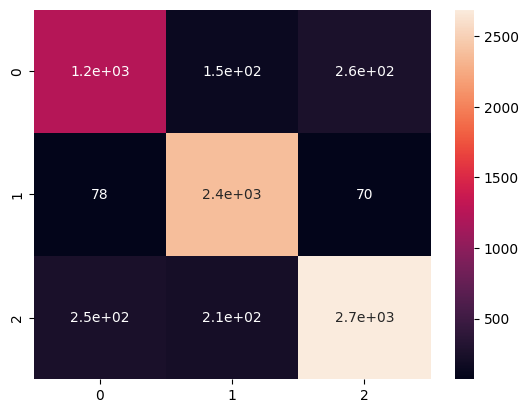

In [17]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot = True)